# Predicción de Precios de Casas Usando Aprendizaje Profundo (ANN)


Lucho Ene | 2022 <br>
Way down We Go by Kaleo

El sistema de predicción de precios de casas está diseñado para predecir precios basándose en diversas características como ubicación, detalles de las habitaciones y otras comodidades. El sistema utiliza un modelo de red neuronal implementado con el framework **Keras**.  
Además, se ha desarrollado una aplicación web con **Flask** para ofrecer una interfaz intuitiva que permita a los usuarios ingresar datos y recibir predicciones de precios.

## Import Packages 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,mean_squared_log_error
import pickle

from keras.models import Sequential 
from keras.layers import Dense, Dropout 
from keras.callbacks import EarlyStopping 
import sklearn
import tensorflow as tf
import keras


## Import Datasets

In [2]:
df = pd.read_csv(r"housing.csv")
df_raw = df.copy()
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [5]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.dropna(axis=0, inplace=True)

In [8]:
df.shape

(20433, 10)

In [9]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [10]:
df['ocean_proximity'] = df['ocean_proximity'].map({"<1H OCEAN":0,"INLAND":1,"NEAR OCEAN":2,"NEAR BAY":3,"ISLAND":4})

In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


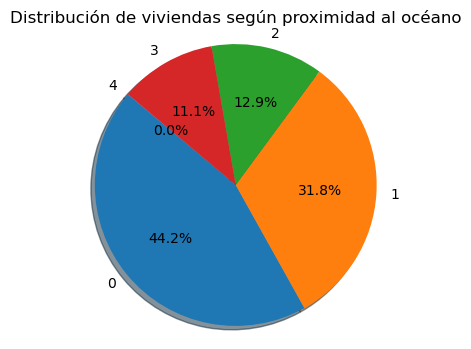

In [12]:
# Crear el gráfico de torta
ocean_counts = df['ocean_proximity'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    ocean_counts,
    labels=ocean_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True
)
plt.title('Distribución de viviendas según proximidad al océano')
plt.axis('equal') 
plt.show()

### Train & Test

In [13]:
y = df['median_house_value']
x = df.drop('median_house_value', axis=1)
print(x.shape)
print(y.shape)

(20433, 9)
(20433,)


In [14]:
x = np.array(x)
y = np.array(y)

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16346, 9)
(4087, 9)
(16346,)
(4087,)


In [16]:
min_max_scaler = MinMaxScaler()
x_train = min_max_scaler.fit_transform(x_train)
x_test = min_max_scaler.transform(x_test)

In [17]:
print(x_train)
print(x_test)

[[0.54425229 0.30180659 0.66666667 ... 0.06101974 0.21336947 0.25      ]
 [0.30315361 0.58448459 0.56862745 ... 0.00707237 0.27586516 0.25      ]
 [0.6948118  0.16790648 0.09803922 ... 0.25542763 0.25377581 0.25      ]
 ...
 [0.23601221 0.51328374 0.68627451 ... 0.05411184 0.2810375  0.        ]
 [0.19226857 0.55366631 1.         ... 0.06069079 0.26132053 0.75      ]
 [0.51068159 0.19978746 0.43137255 ... 0.12648026 0.29727866 0.5       ]]
[[0.71922686 0.02231668 0.43137255 ... 0.09769737 0.18199749 0.5       ]
 [0.30620549 0.64718385 0.45098039 ... 0.07976974 0.19436284 0.25      ]
 [0.3387589  0.54091392 0.74509804 ... 0.09917763 0.08313678 0.25      ]
 ...
 [0.15055951 0.62274176 0.76470588 ... 0.06973684 0.23342437 0.        ]
 [0.6103764  0.17534538 1.         ... 0.04276316 0.29645798 0.        ]
 [0.72227874 0.08926674 0.25490196 ... 0.13289474 0.31384395 0.        ]]


In [18]:
x_train.shape[1]


9

#### Creacion de la red

In [19]:
model = Sequential([
    #input layer
    Dense(1000, input_shape=(x_train.shape[1],), activation='relu'),
    Dropout(0.2),
    #two hidden layers
    Dense(500, activation='relu'),
    Dropout(0.2),
    Dense(250, activation='relu'),
    #output layer
    Dense(1,activation='linear') # here 1 shows countinuous value(regression) 
])
model.summary()

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,001 (2.43 MB)

 Trainable params: 636,001 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

- **Parámetros Totales**:  
  La sección **"Total params"** indica que el modelo tiene un total de **636,001 parámetros**. Estos son los pesos y sesgos (*biases*) que el modelo aprenderá durante el entrenamiento.

- **Parámetros Entrenables**:  
  La sección **"Trainable params"** muestra que los **636,001 parámetros** del modelo son entrenables, lo que significa que serán actualizados y ajustados durante el entrenamiento para optimizar el rendimiento del modelo.

- **Parámetros No Entrenables**:  
  La sección **"Non-trainable params"** normalmente es **0**, lo cual indica que **no hay parámetros** que permanezcan sin cambios durante el entrenamiento.

In [20]:
# Compilar el modelo y configurar early stopping
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

# EarlyStopping: detener el entrenamiento si la pérdida de validación no mejora
es = EarlyStopping(
    monitor='val_loss',      # Supervisar la pérdida en los datos de validación
    mode='min',              # Buscar el valor mínimo de la pérdida
    patience=50,             # Número de épocas sin mejora antes de detenerse
    restore_best_weights=True  # Restaurar los mejores pesos obtenidos
)

In [21]:
# Entrenamiento del modelo
history = model.fit(x_train, y_train, validation_data= (x_test, y_test), callbacks=[es], epochs=10, batch_size=50, verbose=1)

Epoch 1/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 23978459136.0000 - mae: 118646.0938 - val_loss: 10426620928.0000 - val_mae: 79978.0469
Epoch 2/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 9157280768.0000 - mae: 75852.8203 - val_loss: 6831488000.0000 - val_mae: 62618.4727
Epoch 3/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6270903808.0000 - mae: 59429.3945 - val_loss: 5673455104.0000 - val_mae: 54356.6523
Epoch 4/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5894154752.0000 - mae: 56264.6680 - val_loss: 5446848000.0000 - val_mae: 54834.4688
Epoch 5/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5717052416.0000 - mae: 55187.3164 - val_loss: 5260806656.0000 - val_mae: 52602.6445
Epoch 6/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5526025728.0000 - mae: 53968.6953 - val_loss: 5088735744.0000 - val_mae: 52099.6211
Epoch 7/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5353339904.0000 - mae: 53030.6914 - val_loss: 4958574080.0000 - val_mae: 

In [22]:
y_pred = model.predict(x_test)
print("mae :", mean_absolute_error(y_test,y_pred))
print("mse :", mean_squared_error(y_test,y_pred))
print("mae :", mean_squared_log_error(y_test,y_pred))
print("score :", r2_score(y_test,y_pred))

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
mae : 47835.06895338879
mse : 4505988232.963144
mae : 0.10795449585265673
score : 0.6485692741358067


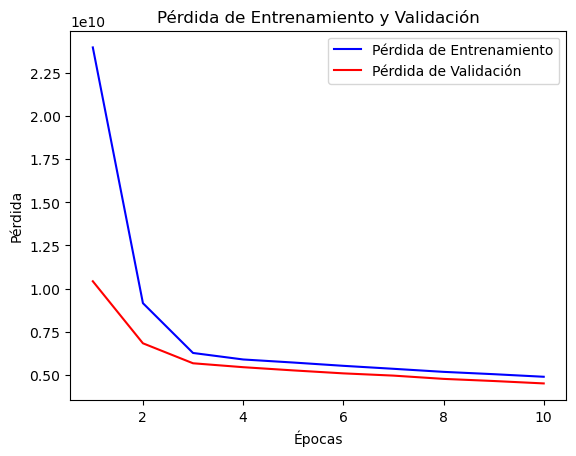

In [23]:
# Obtener la pérdida de entrenamiento y validación del objeto history
perdida_entrenamiento = history.history['loss']
perdida_validacion = history.history['val_loss']
epocas = range(1, len(perdida_entrenamiento) + 1)

# Graficar la pérdida de entrenamiento y validación
plt.plot(epocas, perdida_entrenamiento, 'b', label='Pérdida de Entrenamiento')
plt.plot(epocas, perdida_validacion, 'r', label='Pérdida de Validación')

# Etiquetar el gráfico
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Mostrar el gráfico
plt.show()

511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


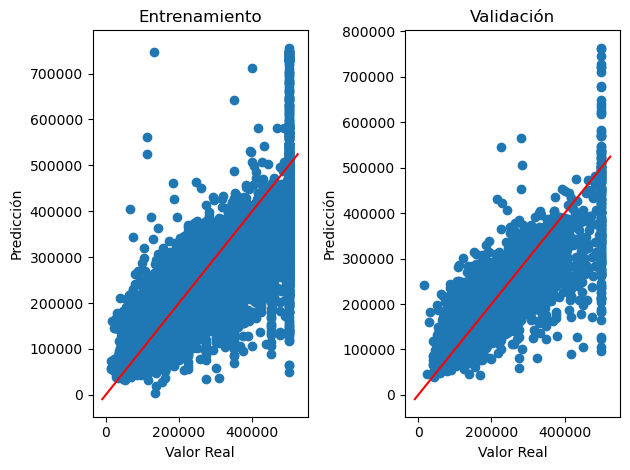

In [24]:
# Especificar las dimensiones del gráfico
fig, axes = plt.subplots(1, 2)

# Crear los subgráficos individuales

# Resultados del entrenamiento
axes[0].scatter(x=y_train, y=model.predict(x_train))
axes[0].set_xlabel('Valor Real', fontsize=10)
axes[0].set_ylabel('Predicción', fontsize=10)
axes[0].set_title('Entrenamiento')

# Agregar línea de 45 grados (ideal donde Predicción = Valor Real)
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')

# Resultados de la validación
axes[1].scatter(x=y_test, y=model.predict(x_test))
axes[1].set_xlabel('Valor Real', fontsize=10)
axes[1].set_ylabel('Predicción', fontsize=10)
axes[1].set_title('Validación')

# Agregar línea de 45 grados
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# Ajustar automáticamente el diseño para que no se solapen los elementos
fig.tight_layout()

# Mostrar el gráfico
plt.show()

#### Sistema de prediccion

In [25]:
def pred(longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity):
    features = np.array([longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity])
    features_scaled = min_max_scaler.fit_transform([features])
    results = model.predict(features_scaled).reshape(1,-1)
    return results[0]

In [26]:
longitude = -122.2300
latitude  = 37.8800
housing_median_age  = 41.0000
total_rooms        = 880.0000
total_bedrooms   =  129.0000
population     = 322.0000
households          =    126.0000
median_income       =      8.3252
ocean_proximity       =     3.0000

price = pred(longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [27]:
price 


array([282694.38], dtype=float32)

##### Guardar el modelo

In [28]:
model.save("model_ann.h5")

pickle.dump(min_max_scaler,open('scaler.pkl','wb'))

#### Checkeo de Version

In [29]:
print("scikit-learn version:", sklearn.__version__)
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

scikit-learn version: 1.5.1
TensorFlow version: 2.19.0
Keras version: 3.11.2
